/tmp/ipython-input-2457322290.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accuracy_model = dfhuman.groupby('distance')['correct'].mean()
/tmp/ipython-input-2457322290.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accuracy_human = dfmodel.groupby('distance')['correct'].mean()
/tmp/ipython-input-2457322290.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  reaction_model = dfhuman.groupby('distance')['rea

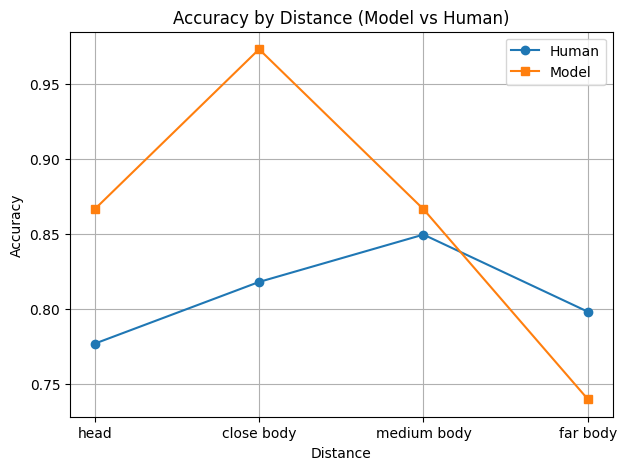

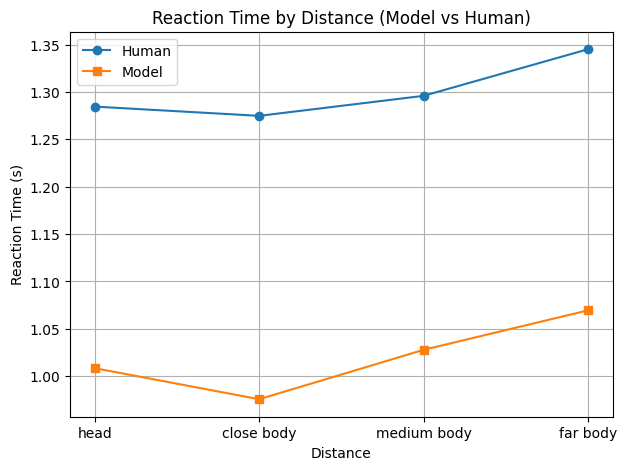

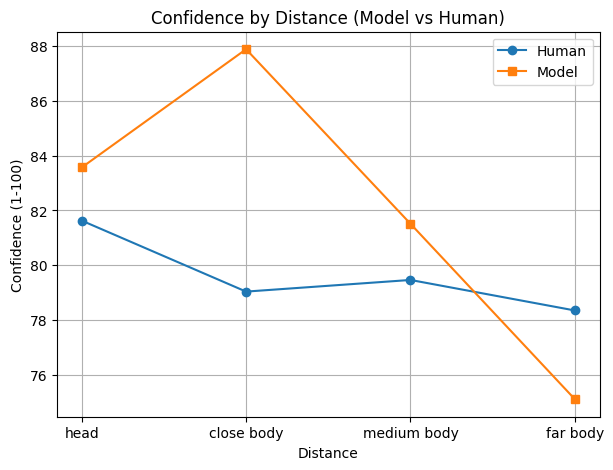

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

filesmodel = [
    '/content/finalresults.csv',
    '/content/finalresults2.csv',
    '/content/results1.csv',
    '/content/results2.csv'
]
dfhuman = pd.concat([pd.read_csv(f) for f in filesmodel], ignore_index=True)

def clean_category_model(x):
    x = x.strip().lower()
    if x == 'animall':
        return 'animal'
    elif x == 'nonanimall':
        return 'nonanimal'
    return x

dfhuman['category'] = dfhuman['category'].apply(clean_category_model)
dfhuman['correct'] = dfhuman['correct'].astype(int)

distance_map_model = {
    'Head': 'head',
    'CloseBody': 'close body',
    'MediumBody': 'medium body',
    'FarBody': 'far body'
}
dfhuman['distance'] = dfhuman['distance'].replace(distance_map_model)

fileshuman = ['/content/data_with_decision_and_correct.csv']
dfmodel = pd.concat([pd.read_csv(f) for f in fileshuman], ignore_index=True)

def clean_category_human(x):
    x = x.strip().lower()
    if x == 'animal':
        return 'animal'
    elif x == 'non-animal':
        return 'nonanimal'
    return x

dfmodel['category'] = dfmodel['category'].apply(clean_category_human)
dfmodel['correct'] = dfmodel['correct'].astype(int)
distance_order = ['head', 'close body', 'medium body', 'far body']
dfhuman['distance'] = pd.Categorical(dfhuman['distance'], categories=distance_order, ordered=True)
dfmodel['distance'] = pd.Categorical(dfmodel['distance'], categories=distance_order, ordered=True)
accuracy_model = dfhuman.groupby('distance')['correct'].mean()
accuracy_human = dfmodel.groupby('distance')['correct'].mean()
reaction_model = dfhuman.groupby('distance')['reactionTime'].mean()
reaction_human = dfmodel.groupby('distance')['reaction_time'].mean() / 1000
confidence_model = dfhuman.groupby('distance')['confidence'].mean() * 20
confidence_human = dfmodel.groupby('distance')['confidence'].mean()

plt.figure(figsize=(7,5))

plt.plot(distance_order, accuracy_model.values, marker='o', label='Human')
plt.plot(distance_order, accuracy_human.values, marker='s', label='Model')


plt.title('Accuracy by Distance (Model vs Human)')
plt.ylabel('Accuracy')
plt.xlabel('Distance')
plt.grid(True)
plt.legend()
plt.savefig('Accuracy by Distance (Model vs Human).png')
plt.show()

plt.figure(figsize=(7,5))
plt.plot(distance_order, reaction_model.values, marker='o', label='Human')
plt.plot(distance_order, reaction_human.values, marker='s', label='Model')

plt.title('Reaction Time by Distance (Model vs Human)')
plt.ylabel('Reaction Time (s)')
plt.xlabel('Distance')
plt.grid(True)
plt.legend()
plt.savefig('Reaction Time by Distance (Model vs Human).png')
plt.show()
plt.figure(figsize=(7,5))

plt.plot(distance_order, confidence_model.values, marker='o', label='Human')
plt.plot(distance_order, confidence_human.values, marker='s', label='Model')

plt.title('Confidence by Distance (Model vs Human)')
plt.ylabel('Confidence (1-100)')
plt.xlabel('Distance')
plt.grid(True)
plt.legend()
plt.savefig('Confidence by Distance (Model vs Human).png')
plt.show()


/tmp/ipython-input-1377699496.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accuracy_human = dfmodel.groupby('category')['correct'].mean()
/tmp/ipython-input-1377699496.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accuracy_model = dfhuman.groupby('category')['correct'].mean()


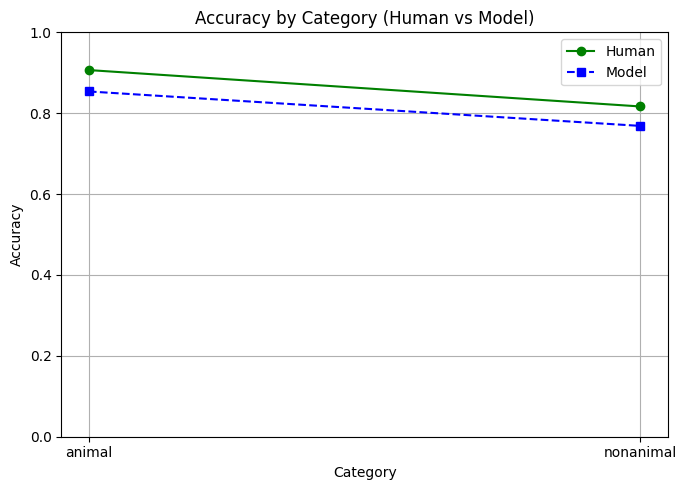

/tmp/ipython-input-1377699496.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rt_correct_h = dfhuman[dfhuman['correct'] == 1].groupby('category')['reactionTime'].agg(['mean', 'sem'])
/tmp/ipython-input-1377699496.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rt_incorrect_h = dfhuman[dfhuman['correct'] == 0].groupby('category')['reactionTime'].agg(['mean', 'sem'])
/tmp/ipython-input-1377699496.py:65: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future

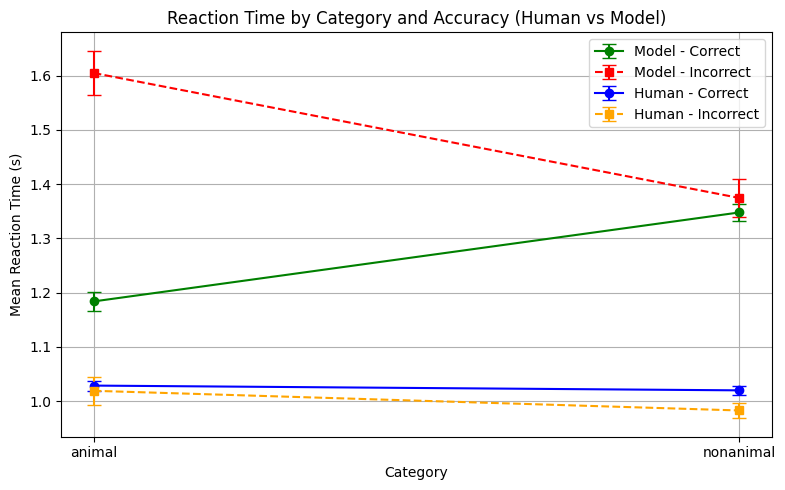

/tmp/ipython-input-1377699496.py:106: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cn_correct_h = dfhuman[dfhuman['correct'] == 1].groupby('category')['confidence'].agg(['mean', 'sem'])*20
/tmp/ipython-input-1377699496.py:107: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cn_incorrect_h = dfhuman[dfhuman['correct'] == 0].groupby('category')['confidence'].agg(['mean', 'sem'])*20
/tmp/ipython-input-1377699496.py:124: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the f

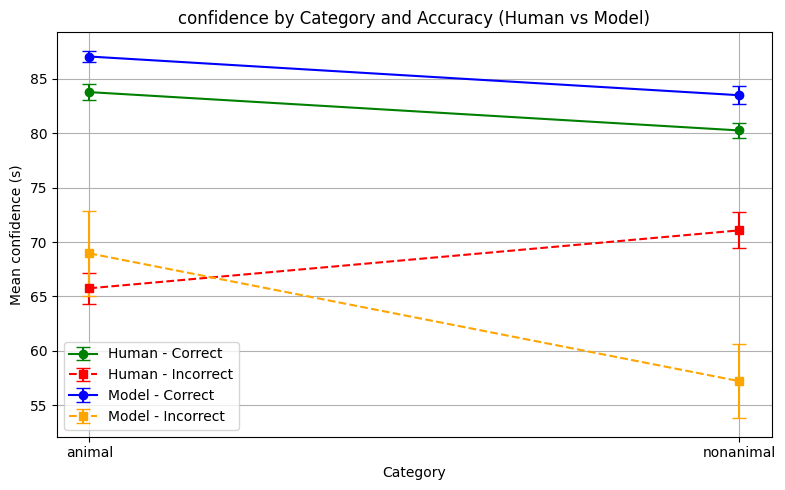

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

dfmodel['category'] = pd.Categorical(dfmodel['category'], categories=['animal', 'nonanimal'], ordered=True)
accuracy_human = dfmodel.groupby('category')['correct'].mean()

dfhuman['category'] = pd.Categorical(dfhuman['category'], categories=['animal', 'nonanimal'], ordered=True)
accuracy_model = dfhuman.groupby('category')['correct'].mean()

categories = accuracy_human.index.tolist()

plt.figure(figsize=(7,5))
plt.plot(categories, accuracy_human.values, marker='o', linestyle='-', label='Human', color='green')
plt.plot(categories, accuracy_model.values, marker='s', linestyle='--', label='Model', color='blue')

plt.title('Accuracy by Category (Human vs Model)')
plt.xlabel('Category')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('Accuracy by Category (Human vs Model).png')
plt.show()


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def clean_category_human(x):
    x = x.strip().lower()
    if x == 'animal':
        return 'animal'
    elif x == 'non-animal':
        return 'nonanimal'
    else:
        return x

dfhuman['category'] = dfhuman['category'].apply(clean_category_human)
dfhuman['correct'] = dfhuman['correct'].astype(int)
dfhuman['category'] = pd.Categorical(dfhuman['category'], categories=['animal', 'nonanimal'], ordered=True)

categories = ['animal', 'nonanimal']
rt_correct_h = dfhuman[dfhuman['correct'] == 1].groupby('category')['reactionTime'].agg(['mean', 'sem'])
rt_incorrect_h = dfhuman[dfhuman['correct'] == 0].groupby('category')['reactionTime'].agg(['mean', 'sem'])



def clean_category_model(x):
    x = x.strip().lower()
    if x == 'animall':
        return 'animal'
    elif x == 'nonanimall':
        return 'nonanimal'
    else:
        return x

dfmodel['category'] = dfmodel['category'].apply(clean_category_model)
dfmodel['correct'] = dfmodel['correct'].astype(int)
dfmodel['category'] = pd.Categorical(dfmodel['category'], categories=['animal', 'nonanimal'], ordered=True)

categoriesmodel = ['animal', 'nonanimal']
rt_correct_m = dfmodel[dfmodel['correct'] == 1].groupby('category')['reaction_time'].agg(['mean', 'sem'])/1000
rt_incorrect_m = dfmodel[dfmodel['correct'] == 0].groupby('category')['reaction_time'].agg(['mean', 'sem'])/1000


plt.figure(figsize=(8,5))

plt.errorbar(categories, rt_correct_h.loc[categories, 'mean'], yerr=rt_correct_h.loc[categories, 'sem'],
             fmt='o-', capsize=5, label='Model - Correct', color='green')
plt.errorbar(categories, rt_incorrect_h.loc[categories, 'mean'], yerr=rt_incorrect_h.loc[categories, 'sem'],
             fmt='s--', capsize=5, label='Model - Incorrect', color='red')

plt.errorbar(categoriesmodel, rt_correct_m.loc[categoriesmodel, 'mean'], yerr=rt_correct_m.loc[categoriesmodel, 'sem'],
             fmt='o-', capsize=5, label='Human - Correct', color='blue')
plt.errorbar(categoriesmodel, rt_incorrect_m.loc[categoriesmodel, 'mean'], yerr=rt_incorrect_m.loc[categoriesmodel, 'sem'],
             fmt='s--', capsize=5, label='Human - Incorrect', color='orange')

plt.title('Reaction Time by Category and Accuracy (Human vs Model)')
plt.xlabel('Category')
plt.ylabel('Mean Reaction Time (s)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('Reaction Time by Category and Accuracy (Human vs Model).png')
plt.show()



def clean_category_human(x):
    x = x.strip().lower()
    if x == 'animal':
        return 'animal'
    elif x == 'non-animal':
        return 'nonanimal'
    else:
        return x

dfhuman['category'] = dfhuman['category'].apply(clean_category_human)
dfhuman['correct'] = dfhuman['correct'].astype(int)
dfhuman['category'] = pd.Categorical(dfhuman['category'], categories=['animal', 'nonanimal'], ordered=True)

categories = ['animal', 'nonanimal']
cn_correct_h = dfhuman[dfhuman['correct'] == 1].groupby('category')['confidence'].agg(['mean', 'sem'])*20
cn_incorrect_h = dfhuman[dfhuman['correct'] == 0].groupby('category')['confidence'].agg(['mean', 'sem'])*20


def clean_category_model(x):
    x = x.strip().lower()
    if x == 'animall':
        return 'animal'
    elif x == 'nonanimall':
        return 'nonanimal'
    else:
        return x

dfmodel['category'] = dfmodel['category'].apply(clean_category_model)
dfmodel['correct'] = dfmodel['correct'].astype(int)
dfmodel['category'] = pd.Categorical(dfmodel['category'], categories=['animal', 'nonanimal'], ordered=True)

categoriesmodel = ['animal', 'nonanimal']
cn_correct_m = dfmodel[dfmodel['correct'] == 1].groupby('category')['confidence'].agg(['mean', 'sem'])
cn_incorrect_m = dfmodel[dfmodel['correct'] == 0].groupby('category')['confidence'].agg(['mean', 'sem'])


plt.figure(figsize=(8,5))

plt.errorbar(categories, cn_correct_h.loc[categories, 'mean'], yerr=cn_correct_h.loc[categories, 'sem'],
             fmt='o-', capsize=5, label='Human - Correct', color='green')
plt.errorbar(categories, cn_incorrect_h.loc[categories, 'mean'], yerr=cn_incorrect_h.loc[categories, 'sem'],
             fmt='s--', capsize=5, label='Human - Incorrect', color='red')

plt.errorbar(categoriesmodel, cn_correct_m.loc[categoriesmodel, 'mean'], yerr=cn_correct_m.loc[categoriesmodel, 'sem'],
             fmt='o-', capsize=5, label='Model - Correct', color='blue')
plt.errorbar(categoriesmodel, cn_incorrect_m.loc[categoriesmodel, 'mean'], yerr=cn_incorrect_m.loc[categoriesmodel, 'sem'],
             fmt='s--', capsize=5, label='Model - Incorrect', color='orange')

plt.title('confidence by Category and Accuracy (Human vs Model)')
plt.xlabel('Category')
plt.ylabel('Mean confidence (s)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('confidence by Category and Accuracy (Human vs Model).png')
plt.show()

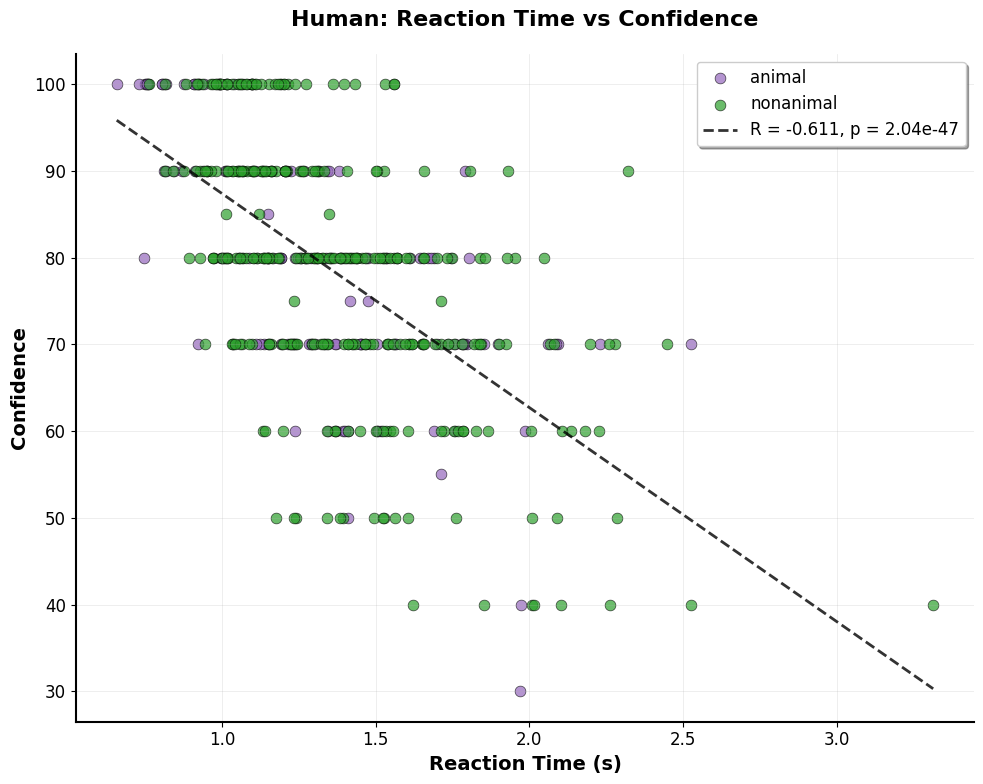

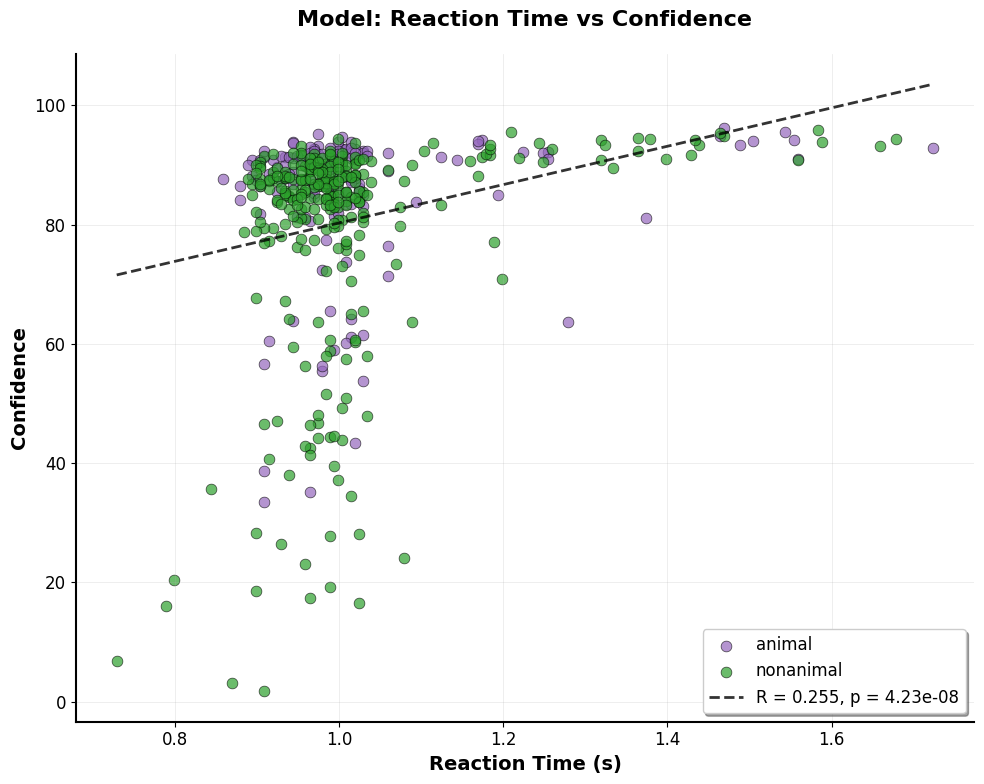


Animal (n=151):
  انسان: R = -0.665, p = 1.221e-20
  مدل: R = 0.179, p = 2.770e-02

Nonanimal (n=300):
  انسان: R = -0.590, p = 1.474e-29
  مدل: R = 0.286, p = 4.917e-07


In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

plt.rcParams['font.size'] = 12

if 'reaction_time' in dfmodel.columns:
    dfmodel.rename(columns={'reaction_time': 'reactionTime'}, inplace=True)

def clean_filename(df):
    """استخراج و تمیز کردن نام فایل‌ها"""
    df['file_clean'] = (df['file']
                       .str.split('\\').str[-1]
                       .str.split('/').str[-1]
                       .str.strip()
                       .str.lower())
    return df

dfhuman = clean_filename(dfhuman.copy())
dfmodel = clean_filename(dfmodel.copy())

human_avg = (dfhuman.groupby(['file_clean', 'category'])
             .agg({'reactionTime': 'mean', 'confidence': 'mean'})
             .reset_index())

model_avg = (dfmodel.groupby(['file_clean', 'category'])
             .agg({'reactionTime': 'mean', 'confidence': 'mean'})
             .reset_index())

model_avg['reactionTime'] = model_avg['reactionTime'] / 1000

human_avg['confidence'] = human_avg['confidence'] * 20

merged = pd.merge(human_avg, model_avg,
                  on=['file_clean', 'category'],
                  suffixes=('_human', '_model'),
                  how='inner')  # فقط تصاویر مشترک


colors = {'animal': '#9467bd', 'nonanimal': '#2ca02c'}

def plot_correlation(x_data, y_data, categories, title, figsize=(10, 8)):


    fig, ax = plt.subplots(figsize=figsize)

    # رسم نقاط برای هر دسته
    for cat in colors:
        mask = categories == cat
        if mask.any():
            ax.scatter(x_data[mask], y_data[mask],
                      color=colors[cat], label=cat,
                      alpha=0.7, s=60, edgecolors='black', linewidth=0.5)

    # محاسبه و رسم خط رگرسیون
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)
    x_line = np.linspace(x_data.min(), x_data.max(), 100)
    y_line = intercept + slope * x_line

    ax.plot(x_line, y_line, 'k--', linewidth=2, alpha=0.8,
            label=f'R = {r_value:.3f}, p = {p_value:.2e}')

    # تنظیمات نمودار
    ax.set_xlabel('Reaction Time (s)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Confidence', fontsize=14, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)

    ax.legend(fontsize=12, frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)

    plt.tight_layout()
    return fig, r_value, p_value


fig_human, r_human, p_human = plot_correlation(
    merged['reactionTime_human'],
    merged['confidence_human'],
    merged['category'],
    'Human: Reaction Time vs Confidence'
)
plt.savefig('Human: Reaction Time vs Confidence')
plt.show()


fig_model, r_model, p_model = plot_correlation(
    merged['reactionTime_model'],
    merged['confidence_model'],
    merged['category'],
    'Model: Reaction Time vs Confidence'
)
plt.savefig('Model: Reaction Time vs Confidence')
plt.show()


for category in ['animal', 'nonanimal']:
    mask = merged['category'] == category
    n_samples = mask.sum()

    if n_samples > 2:

        r_h, p_h = stats.pearsonr(
            merged.loc[mask, 'reactionTime_human'],
            merged.loc[mask, 'confidence_human']
        )

        # مدل
        r_m, p_m = stats.pearsonr(
            merged.loc[mask, 'reactionTime_model'],
            merged.loc[mask, 'confidence_model']
        )

        print(f"\n{category.capitalize()} (n={n_samples}):")
        print(f"  انسان: R = {r_h:.3f}, p = {p_h:.3e}")
        print(f"  مدل: R = {r_m:.3f}, p = {p_m:.3e}")
    else:
        print(f"\n{category.capitalize()}: تعداد نمونه کافی نیست (n={n_samples})")



Original confidence ranges:
Human: 1.0 - 5.0
Model: 1.7077798861480118 - 96.42857142857142
Merged data shape: (451, 6)
Human confidence range: 0.300 - 1.000
Model confidence range: 0.002 - 1.000
Human reaction time range: 0.657 - 3.314
Model reaction time range: 0.729 - 1.724


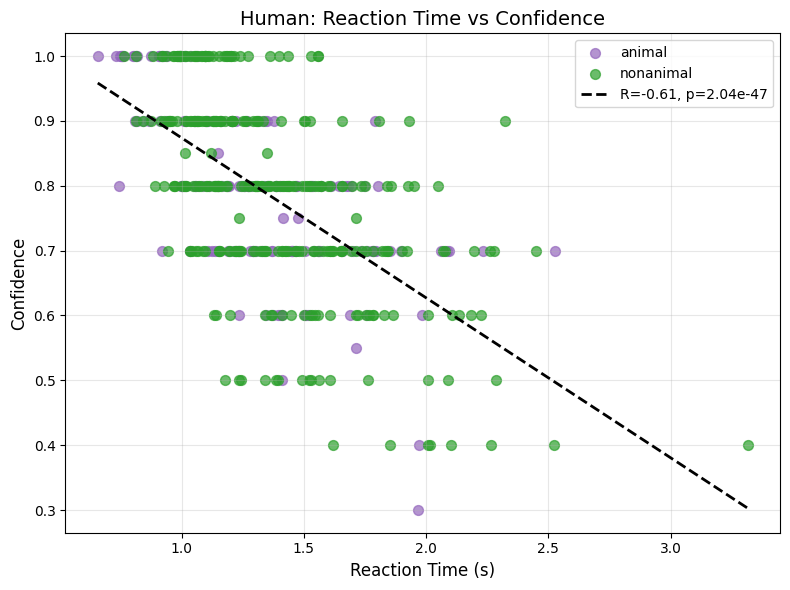

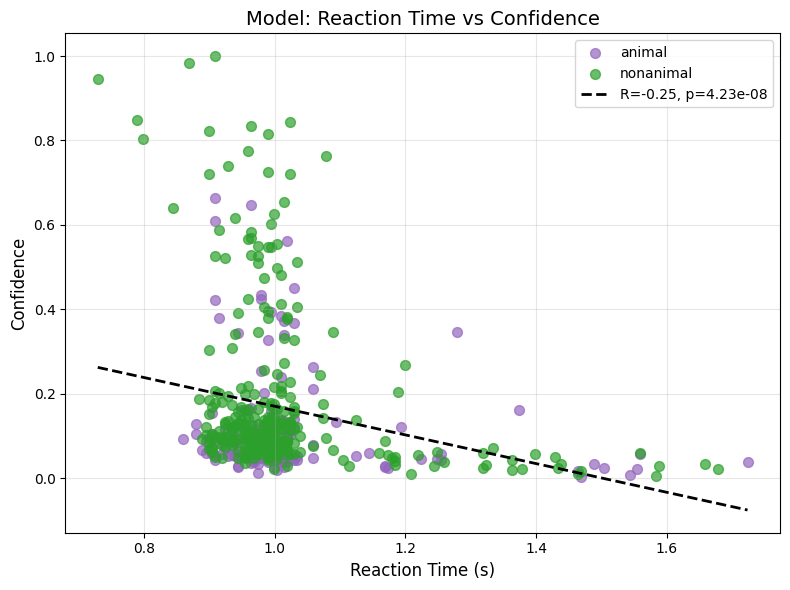


Correlation analysis by category:
Animal:
  Human: R=-0.665, p=1.221e-20
  Model: R=-0.179, p=2.770e-02
Nonanimal:
  Human: R=-0.590, p=1.474e-29
  Model: R=-0.286, p=4.917e-07


In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

# پردازش اولیه داده‌ها
if 'reaction_time' in dfmodel.columns:
    dfmodel.rename(columns={'reaction_time': 'reactionTime'}, inplace=True)

# استخراج نام فایل‌ها
dfhuman['file'] = dfhuman['file'].str.split('\\').str[-1].str.split('/').str[-1]
dfmodel['file'] = dfmodel['file'].str.split('\\').str[-1].str.split('/').str[-1]
dfhuman['file'] = dfhuman['file'].str.strip().str.lower()
dfmodel['file'] = dfmodel['file'].str.strip().str.lower()

# محاسبه میانگین‌ها
human_avg = dfhuman.groupby(['file', 'category']).agg({
    'reactionTime': 'mean',
    'confidence': 'mean'
}).reset_index()

model_avg = dfmodel.groupby(['file', 'category']).agg({
    'reactionTime': 'mean',
    'confidence': 'mean'
}).reset_index()

# تبدیل واحدها - اصلاح شده
model_avg['reactionTime'] = model_avg['reactionTime'] / 1000  # تبدیل به ثانیه

# بررسی محدوده confidence ها قبل از تبدیل
print("Original confidence ranges:")
print(f"Human: {human_avg['confidence'].min()} - {human_avg['confidence'].max()}")
print(f"Model: {model_avg['confidence'].min()} - {model_avg['confidence'].max()}")

# confidence را در مقیاس 0-1 نگه داریم
# اگر confidence انسان بین 0-5 است، تقسیم بر 5 کنیم
if human_avg['confidence'].max() > 1:
    if human_avg['confidence'].max() <= 5:
        human_avg['confidence'] = human_avg['confidence'] / 5
    elif human_avg['confidence'].max() <= 100:
        human_avg['confidence'] = human_avg['confidence'] / 100

# برای مدل، اگر confidence معکوس است (یعنی عدد بزرگتر = اطمینان کمتر)
# آن را معکوس می‌کنیم
# روش 1: اگر confidence مدل بین 0-1 است و باید معکوس شود
if model_avg['confidence'].max() <= 1:
    model_avg['confidence'] = 1 - model_avg['confidence']
# روش 2: اگر confidence مدل بزرگتر از 1 است
elif model_avg['confidence'].max() > 1:
    max_conf = model_avg['confidence'].max()
    model_avg['confidence'] = max_conf - model_avg['confidence']
    # سپس نرمال‌سازی به 0-1
    model_avg['confidence'] = (model_avg['confidence'] - model_avg['confidence'].min()) / (model_avg['confidence'].max() - model_avg['confidence'].min())

# ادغام داده‌ها
merged = pd.merge(human_avg, model_avg, on=['file', 'category'], suffixes=('_human', '_model'))

print(f"Merged data shape: {merged.shape}")
print(f"Human confidence range: {merged['confidence_human'].min():.3f} - {merged['confidence_human'].max():.3f}")
print(f"Model confidence range: {merged['confidence_model'].min():.3f} - {merged['confidence_model'].max():.3f}")
print(f"Human reaction time range: {merged['reactionTime_human'].min():.3f} - {merged['reactionTime_human'].max():.3f}")
print(f"Model reaction time range: {merged['reactionTime_model'].min():.3f} - {merged['reactionTime_model'].max():.3f}")

# رسم نمودار انسان
plt.figure(figsize=(8, 6))
x = merged['reactionTime_human']
y = merged['confidence_human']
categories = merged['category']
colors = {'animal': '#9467bd', 'nonanimal': '#2ca02c'}  # بنفش و سبز مثل پیپر

for cat in colors:
    mask = categories == cat
    plt.scatter(x[mask], y[mask], color=colors[cat], label=cat, alpha=0.7, s=50)

# رگرسیون خطی
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, intercept + slope*x_line, 'k--', linewidth=2,
         label=f'R={r_value:.2f}, p={p_value:.2e}')

plt.xlabel('Reaction Time (s)', fontsize=12)
plt.ylabel('Confidence', fontsize=12)
plt.title('Human: Reaction Time vs Confidence', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# رسم نمودار مدل
plt.figure(figsize=(8, 6))
x = merged['reactionTime_model']
y = merged['confidence_model']

for cat in colors:
    mask = categories == cat
    plt.scatter(x[mask], y[mask], color=colors[cat], label=cat, alpha=0.7, s=50)

# رگرسیون خطی
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, intercept + slope*x_line, 'k--', linewidth=2,
         label=f'R={r_value:.2f}, p={p_value:.2e}')

plt.xlabel('Reaction Time (s)', fontsize=12)
plt.ylabel('Confidence', fontsize=12)
plt.title('Model: Reaction Time vs Confidence', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# بررسی همبستگی جداگانه برای هر دسته
print("\nCorrelation analysis by category:")
for category in ['animal', 'nonanimal']:
    mask = merged['category'] == category

    # Human
    r_human, p_human = stats.pearsonr(merged.loc[mask, 'reactionTime_human'],
                                     merged.loc[mask, 'confidence_human'])

    # Model
    r_model, p_model = stats.pearsonr(merged.loc[mask, 'reactionTime_model'],
                                     merged.loc[mask, 'confidence_model'])

    print(f"{category.capitalize()}:")
    print(f"  Human: R={r_human:.3f}, p={p_human:.3e}")
    print(f"  Model: R={r_model:.3f}, p={p_model:.3e}")